# Feature Engineering

In [109]:
import os
import zipfile
import shutil
import io
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
# File paths
zillow_path = '/content/drive/MyDrive/DATASCI 210/zillow_rental_data.csv'
house_path = '/content/drive/MyDrive/DATASCI 210/HouseTS.csv'

In [112]:
# Read data
zillow_zori = pd.read_csv(zillow_path)
house_data = pd.read_csv(house_path)

print("Zillow shape:", zillow_zori.shape)
print("HouseTS shape:", house_data.shape)

Zillow shape: (8022, 137)
HouseTS shape: (884092, 39)


In [113]:
# Zillow Data Preparation
# Filter for New York State
zillow_ny = zillow_zori[zillow_zori['State'] == 'NY']

# Select relevant columns (RegionName + date columns)
zillow_cols = ['RegionName', 'City', 'CountyName'] + list(zillow_ny.columns[33:117])
zillow_ny = zillow_ny[zillow_cols].rename(columns={'RegionName': 'zipcode'})

# Keep only non-null values from 2017 onward
zillow_ny = zillow_ny[zillow_ny['2017-01-31'].notna()].reset_index(drop=True)

# Reshape from wide → long format
zillow_long = zillow_ny.melt(
    id_vars=["zipcode", "City", "CountyName"],
    var_name="date",
    value_name="median_rent"
)

# Convert to datetime
zillow_long["date"] = pd.to_datetime(zillow_long["date"])
zillow_long = zillow_long.rename(columns={'City': 'city', 'CountyName': 'county'})

# NYC zipcodes list
zillow_zips = zillow_long['zipcode'].unique().tolist()

print("Zillow NYC data:", zillow_long.shape)
zillow_long.head()


Zillow NYC data: (6552, 5)


,zipcode,city,county,date,median_rent
0,11385,New York,Queens County,2017-01-31,2303.742913
1,10467,New York,Bronx County,2017-01-31,1320.387659
2,11226,New York,Kings County,2017-01-31,2333.401703
3,11207,New York,Kings County,2017-01-31,2184.043420
4,10025,New York,New York County,2017-01-31,3184.747277


In [114]:
#HouseTS Data Preparation
# Convert date column
house_data['date'] = pd.to_datetime(house_data['date'])

# Filter NYC records and date range (2017+)
house_data_nyc = house_data[(house_data['city'] == 'NY') &
                            (house_data['date'] >= pd.to_datetime('2017-01-01'))].reset_index(drop=True)

# Keep only ZIPs also in Zillow data
house_data_nyc = house_data_nyc[house_data_nyc['zipcode'].isin(zillow_zips)]

print("HouseTS NYC data:", house_data_nyc.shape)
house_data_nyc.head()


HouseTS NYC data: (6300, 39)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
31836,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City
31837,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City
31838,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City
31839,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City
31840,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City


### Merge Zillow + HouseTS

In [115]:
house_data_nyc = house_data_nyc.merge(
    right=zillow_long,
    how='left',
    on=['zipcode', 'date'],
    suffixes=("_ts", "_zlw")
)

print("Merged dataset shape:", house_data_nyc.shape)
house_data_nyc.head()


Merged dataset shape: (6300, 42)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city_ts,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,city_zlw,county,median_rent
0,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City,New York,New York County,3922.292665
1,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City,New York,New York County,3863.891996
2,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City,New York,New York County,3873.435091
3,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City,New York,New York County,3891.172482
4,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City,New York,New York County,3957.284734


In [116]:
# EDA
house_data_nyc.describe().T


,count,mean,min,25%,50%,75%,max,std
date,6300,2020-07-15 11:25:42.857143040,2017-01-31 00:00:00,2018-10-23 06:00:00,2020-07-15 12:00:00,2022-04-07 12:00:00,2023-12-31 00:00:00,NaN
median_sale_price,6300.0,1045210.225476,125000.0,635500.0,939500.0,1277500.0,5000000.0,622237.67381
median_list_price,6300.0,1138907.311825,156500.0,685999.75,1026748.5,1390041.5,7000000.0,677758.557754
median_ppsf,6300.0,994.075155,170.630225,592.069619,995.316958,1292.11102,3121.694581,481.027691
median_list_ppsf,6300.0,1035.429219,191.666667,621.052632,1034.701846,1352.283658,2748.473071,488.805778
homes_sold,6300.0,64.273492,1.0,24.0,51.0,89.0,351.0,52.19494
pending_sales,6300.0,69.384444,1.0,25.0,53.0,95.0,1374.0,67.606433
new_listings,6300.0,90.261746,1.0,37.0,74.0,126.0,852.0,69.488688
inventory,6300.0,152.414921,4.0,59.0,114.0,213.0,1114.0,126.569309
median_dom,6300.0,143.484286,18.0,84.5,127.25,174.0,2883.5,113.231795


### Missing Values and Data Types

In [132]:
# Check missing values
house_data_nyc.isnull().sum().sort_values(ascending=False).head(10)

# Fill or drop NA values in key variables
house_data_nyc['median_rent'] = house_data_nyc['median_rent'].fillna(house_data_nyc['median_rent'].median())


###  Seasonality Features

In [147]:
# Temporal features (month, quarter, year already exist)
house_data_nyc['month'] = house_data_nyc['date'].dt.month
house_data_nyc['quarter'] = house_data_nyc['date'].dt.quarter
house_data_nyc['year'] = house_data_nyc['date'].dt.year

# Encode season
season_map = {12:'winter', 1:'winter', 2:'winter',
              3:'spring', 4:'spring', 5:'spring',
              6:'summer', 7:'summer', 8:'summer',
              9:'fall', 10:'fall', 11:'fall'}
house_data_nyc['season'] = house_data_nyc['month'].map(season_map)

# One-hot encode season
house_data_nyc = pd.get_dummies(house_data_nyc, columns=['season'], drop_first=True)

# Capture previous month’s rent/price to model temporal dependence.
house_data_nyc['rent_lag1'] = house_data_nyc.groupby('zipcode')['median_rent'].shift(1)
house_data_nyc['rent_lag3'] = house_data_nyc.groupby('zipcode')['median_rent'].shift(3)
house_data_nyc['price_lag1'] = house_data_nyc.groupby('zipcode')['median_sale_price'].shift(1)

# peak vs off-peak months
house_data_nyc['is_summer'] = house_data_nyc['month'].isin([6,7,8]).astype(int)
house_data_nyc['is_winter'] = house_data_nyc['month'].isin([12,1,2]).astype(int)
house_data_nyc['is_academic_peak'] = house_data_nyc['month'].isin([8,9]).astype(int)


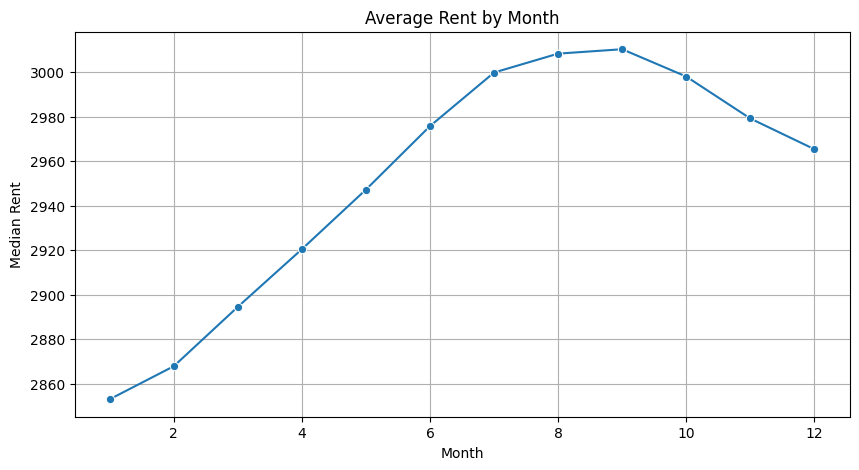

In [148]:
# Plot average rent/price by month
seasonal_avg = house_data_nyc.groupby('month')['median_rent'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=seasonal_avg.index, y=seasonal_avg.values, marker='o')
plt.title("Average Rent by Month")
plt.xlabel("Month")
plt.ylabel("Median Rent")
plt.grid(True)
plt.show()


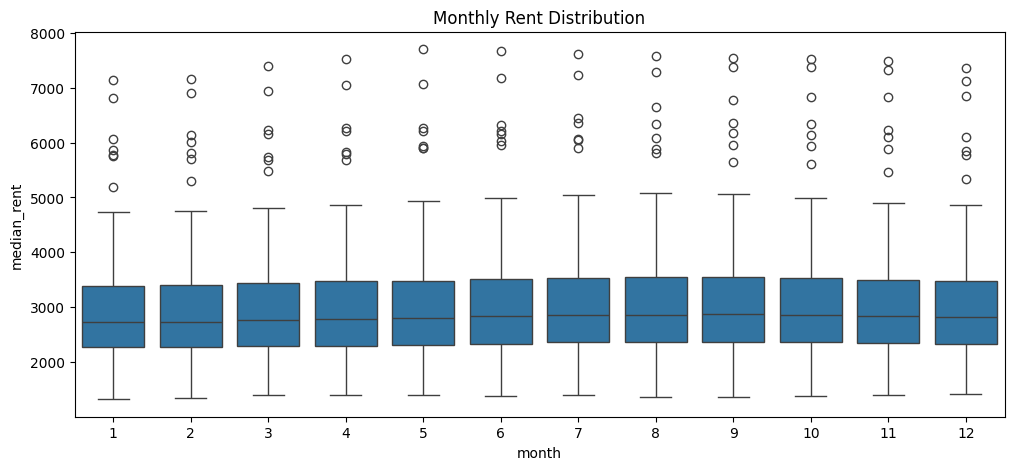

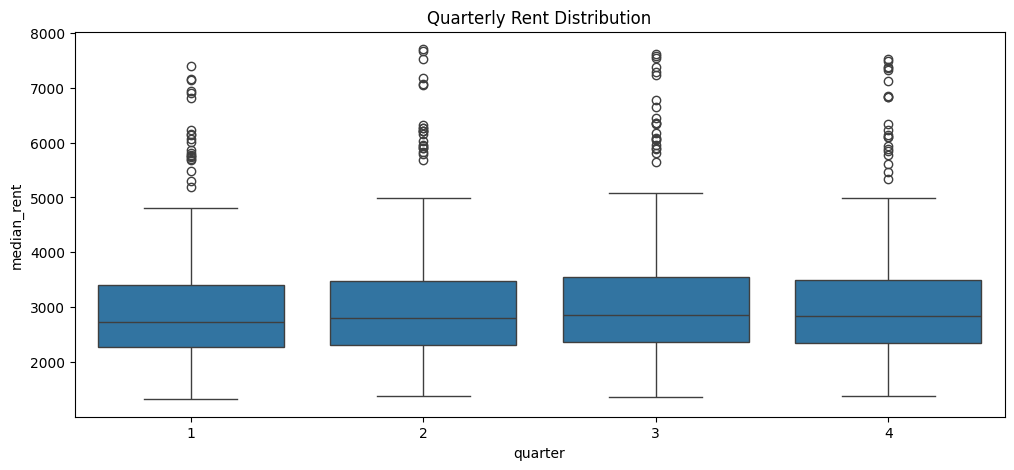

In [149]:
#Show distribution and outliers for each month/season:
plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='median_rent', data=house_data_nyc)
plt.title("Monthly Rent Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='quarter', y='median_rent', data=house_data_nyc)
plt.title("Quarterly Rent Distribution")
plt.show()


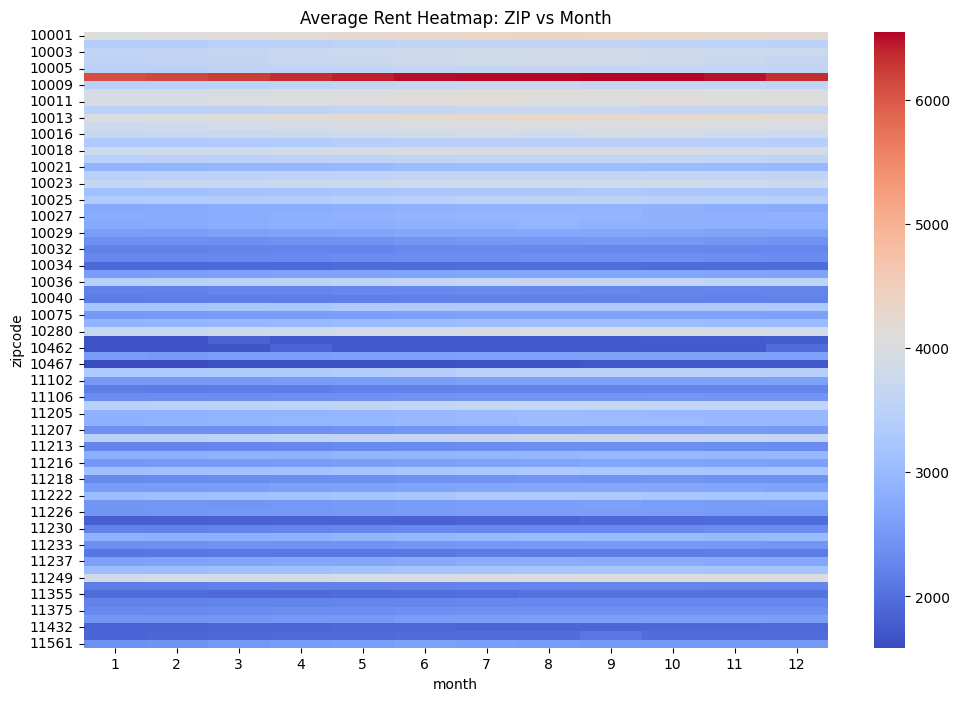

In [150]:
#Heatmap of ZIP vs Month
pivot = house_data_nyc.pivot_table(values='median_rent', index='zipcode', columns='month', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title("Average Rent Heatmap: ZIP vs Month")
plt.show()


### Rolling Averages

In [120]:
# Sort by ZIP and date
house_data_nyc = house_data_nyc.sort_values(['zipcode', 'date'])

# 3-, 6-, 12-month moving averages
for window in [3, 6, 12]:
    house_data_nyc[f'rent_ma_{window}'] = house_data_nyc.groupby('zipcode')['median_rent'].transform(lambda x: x.rolling(window, min_periods=1).mean())
    house_data_nyc[f'price_ma_{window}'] = house_data_nyc.groupby('zipcode')['median_sale_price'].transform(lambda x: x.rolling(window, min_periods=1).mean())


In [121]:
# Ensure data is sorted by date per zipcode
house_data_nyc = house_data_nyc.sort_values(['zipcode', 'date'])

# Rolling averages for rent and price
for col in ['median_rent', 'median_sale_price']:
    house_data_nyc[f'{col}_roll3'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(3).mean())
    house_data_nyc[f'{col}_roll6'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(6).mean())
    house_data_nyc[f'{col}_roll12'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(12).mean())


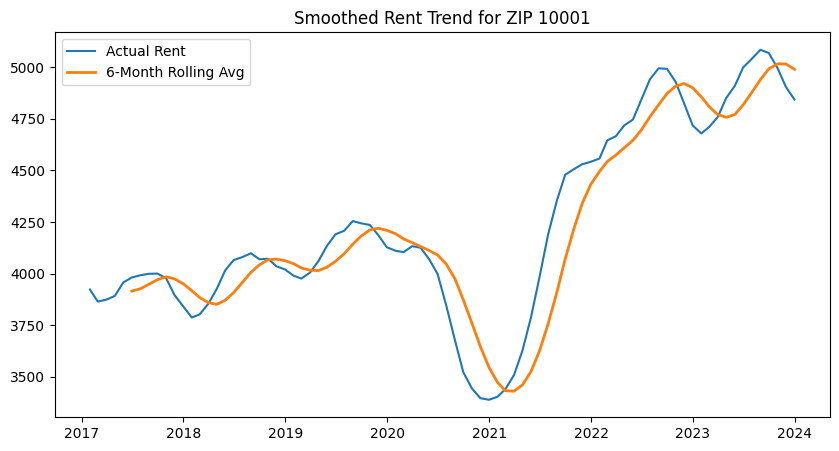

In [122]:
# Compare raw vs smoothed rent for a sample ZIP
sample_zip = 10001
temp = house_data_nyc[house_data_nyc['zipcode'] == sample_zip]
plt.figure(figsize=(10,5))
plt.plot(temp['date'], temp['median_rent'], label='Actual Rent')
plt.plot(temp['date'], temp['median_rent_roll6'], label='6-Month Rolling Avg', linewidth=2)
plt.legend(); plt.title(f"Smoothed Rent Trend for ZIP {sample_zip}")
plt.show()


### Relative Affordability (Zip vs State Avg)

In [123]:
# Calculate state-level average rent and price by date
state_avg = house_data_nyc.groupby('date')[['median_rent','median_sale_price']].mean().reset_index()
state_avg = state_avg.rename(columns={'median_rent':'state_rent_avg','median_sale_price':'state_price_avg'})

# Merge back
house_data_nyc = house_data_nyc.merge(state_avg, on='date', how='left')

# Relative affordability metrics
house_data_nyc['rel_rent'] = house_data_nyc['median_rent'] / house_data_nyc['state_rent_avg']
house_data_nyc['rel_price'] = house_data_nyc['median_sale_price'] / house_data_nyc['state_price_avg']

In [136]:
house_data_nyc['rel_rent'].head()

,rel_rent
0,1.469488
1,1.445119
2,1.442181
3,1.439306
4,1.451929


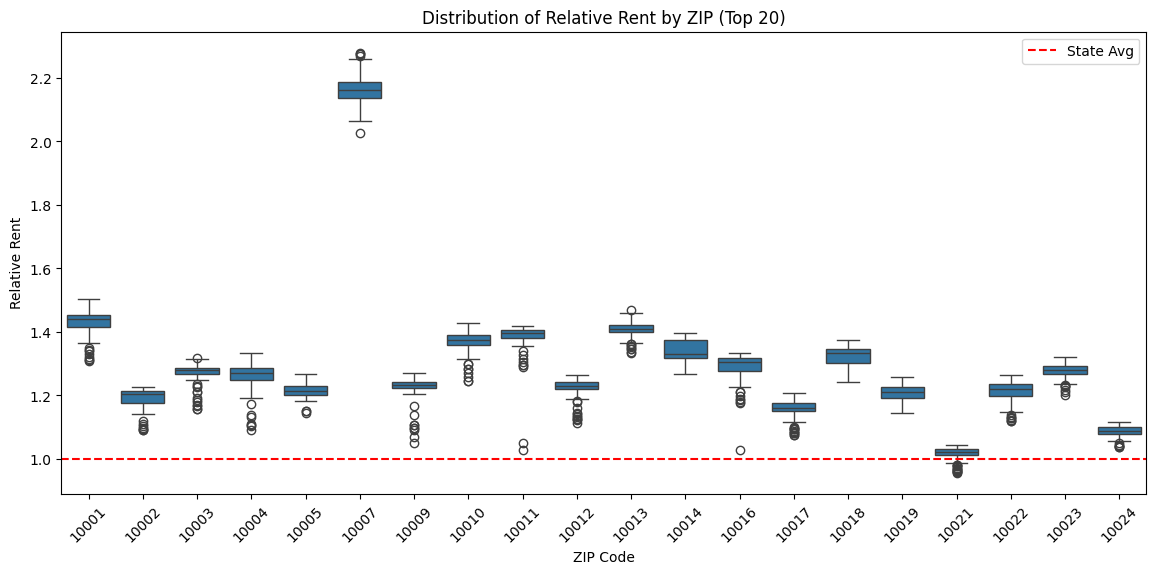

In [144]:
plt.figure(figsize=(14,6))
top_zips = house_data_nyc['zipcode'].value_counts().index[:20]  # top 20 ZIPs
sns.boxplot(data=house_data_nyc[house_data_nyc['zipcode'].isin(top_zips)],
            x='zipcode', y='rel_rent')
plt.axhline(1, color='red', linestyle='--', label='State Avg')
plt.title("Distribution of Relative Rent by ZIP (Top 20)")
plt.xlabel("ZIP Code")
plt.ylabel("Relative Rent")
plt.xticks(rotation=45)
plt.legend()
plt.show()


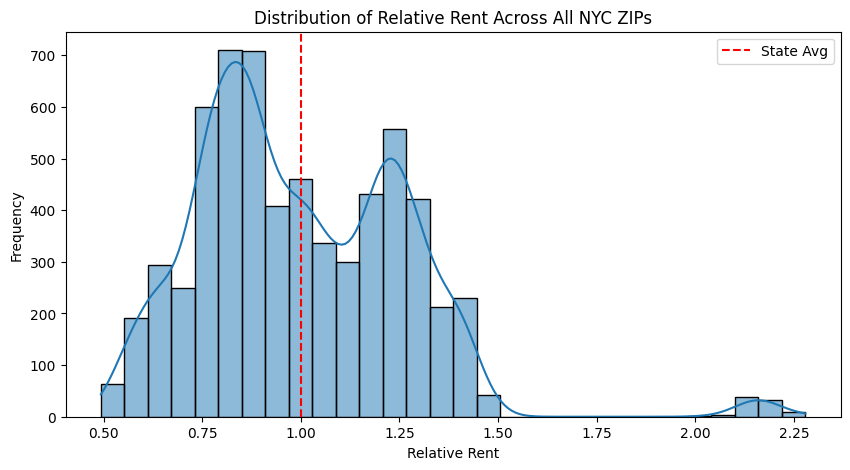

In [146]:
plt.figure(figsize=(10,5))
sns.histplot(house_data_nyc['rel_rent'], bins=30, kde=True)
plt.axvline(1, color='red', linestyle='--', label='State Avg')
plt.title("Distribution of Relative Rent Across All NYC ZIPs")
plt.xlabel("Relative Rent")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Inflation and CPI rate

In [125]:
# Load CPI file
cpi_path = '/content/drive/MyDrive/DATASCI 210/CPI_data.xlsx'
cpi_raw = pd.read_excel(cpi_path)

# Keep only the "Original Data Value" row (ignore % change)
cpi = cpi_raw[cpi_raw['View Description'] == 'Original Data Value'].copy()

# Drop identifier columns
cpi = cpi.drop(columns=['Series ID', 'View Description'])

# Melt from wide to long format
cpi_long = cpi.melt(var_name='month_year', value_name='CPI')

# Clean up month-year strings
# Some columns have line breaks or extra spaces (e.g. "Jan\n2017")
cpi_long['month_year'] = cpi_long['month_year'].str.replace('\n', ' ', regex=True).str.strip()

# Convert to datetime
cpi_long['month_year'] = pd.to_datetime(cpi_long['month_year'], format='%b %Y', errors='coerce')

# Drop any NaN dates
cpi_long = cpi_long.dropna(subset=['month_year'])

# Reset index for a clean DataFrame
cpi_long = cpi_long.reset_index(drop=True)

In [126]:
cpi_long.head()

,month_year,CPI
0,2017-01-01,266.917
1,2017-02-01,267.662
2,2017-03-01,267.582
3,2017-04-01,267.948
4,2017-05-01,268.183


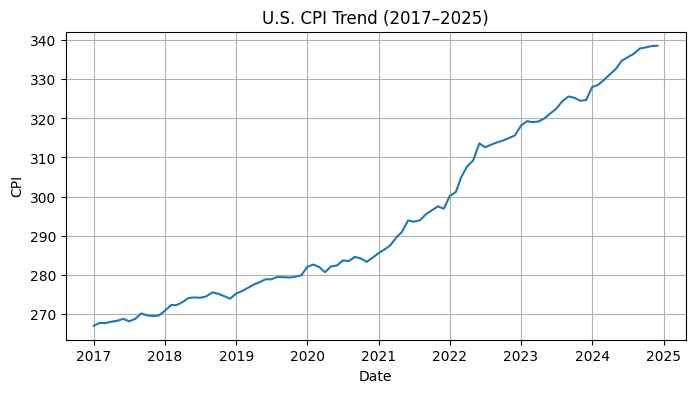

In [128]:
plt.figure(figsize=(8,4))
plt.plot(cpi_long['month_year'], cpi_long['CPI'])
plt.title("U.S. CPI Trend (2017–2025)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.grid(True)
plt.show()


In [127]:
# Extract year-month from both datasets
house_data_nyc['year_month'] = house_data_nyc['date'].dt.to_period('M')
cpi_long['year_month'] = cpi_long['month_year'].dt.to_period('M')

# Merge on year-month
house_data_nyc = house_data_nyc.merge(
    cpi_long[['year_month', 'CPI']],
    on='year_month',
    how='left'
)

# Compute real values now
base_cpi = cpi_long['CPI'].iloc[0]
house_data_nyc['real_rent'] = house_data_nyc['median_rent'] * (base_cpi / house_data_nyc['CPI'])
house_data_nyc['real_price'] = house_data_nyc['median_sale_price'] * (base_cpi / house_data_nyc['CPI'])

# Rent differences
house_data_nyc['rent_diff'] = house_data_nyc['median_rent'] - house_data_nyc['real_rent']
house_data_nyc['rent_pct_diff'] = house_data_nyc['rent_diff'] / house_data_nyc['median_rent'] * 100

# Quick check
print(house_data_nyc[['median_rent', 'real_rent', 'rent_diff', 'rent_pct_diff']].describe())


       median_rent    real_rent    rent_diff  rent_pct_diff
count  6300.000000  6300.000000  6300.000000    6300.000000
mean   2951.659603  2716.028631   235.630972       7.489411
std     849.609716   742.509905   217.186999       5.709006
min    1320.387659  1320.387659     0.000000       0.000000
25%    2316.514524  2161.109812    73.989980       2.751406
50%    2814.952897  2587.481326   156.587656       5.660887
75%    3481.338157  3275.017777   365.458257      12.689080
max    7703.561024  6425.620458  1360.601382      18.026307


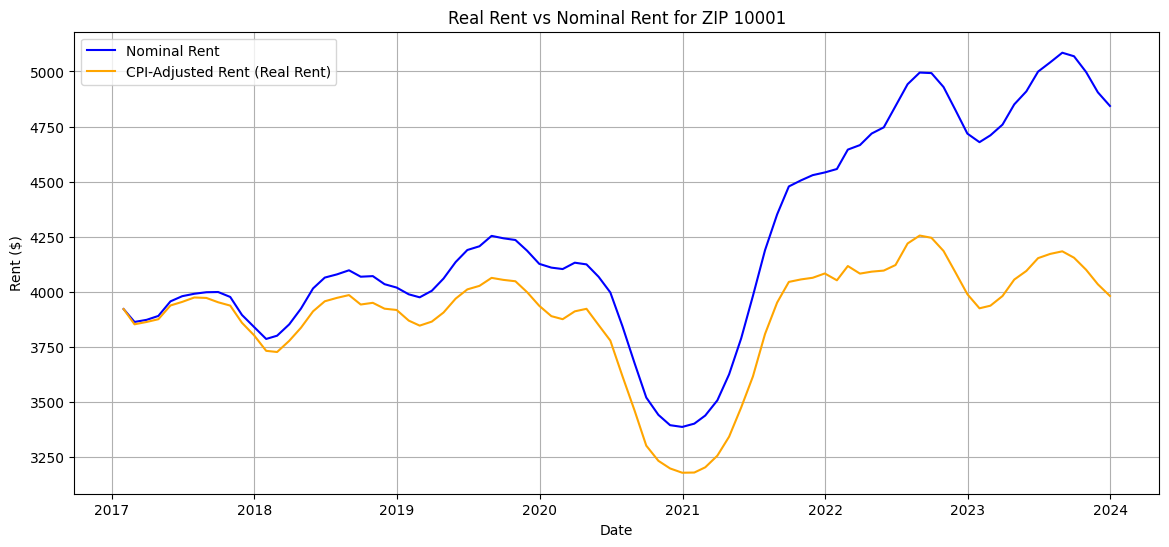

       median_rent    real_rent
count    84.000000    84.000000
mean   4228.617700  3890.444376
std     463.943888   259.088022
min    3387.675731  3179.983271
25%    3949.012252  3852.292681
50%    4100.946119  3946.762451
75%    4669.356247  4055.037059
max    5084.977673  4255.720497
        rent_diff  rent_pct_diff
count   84.000000      84.000000
mean   338.173324       7.489411
std    289.746118       5.742839
min      0.000000       0.000000
25%    112.053714       2.751406
50%    218.236547       5.660887
75%    593.818796      12.689080
max    913.742764      18.026307


In [129]:
# Subset for a single ZIP code or aggregate across NYC
zip_to_plot = 10001  # example ZIP
df_plot = house_data_nyc[house_data_nyc['zipcode'] == zip_to_plot]

plt.figure(figsize=(14,6))
plt.plot(df_plot['date'], df_plot['median_rent'], label='Nominal Rent', color='blue')
plt.plot(df_plot['date'], df_plot['real_rent'], label='CPI-Adjusted Rent (Real Rent)', color='orange')
plt.title(f'Real Rent vs Nominal Rent for ZIP {zip_to_plot}')
plt.xlabel('Date')
plt.ylabel('Rent ($)')
plt.legend()
plt.grid(True)
plt.show()

# Compute summary statistics
comparison = df_plot[['median_rent', 'real_rent']].describe()
print(comparison)

# Optional: compute the difference and percentage difference
df_plot['rent_diff'] = df_plot['median_rent'] - df_plot['real_rent']
df_plot['rent_pct_diff'] = (df_plot['rent_diff'] / df_plot['median_rent']) * 100

# Quick stats on difference
print(df_plot[['rent_diff','rent_pct_diff']].describe())


### Work in Progres

In [133]:
# # sort date
# house_data_nyc = house_data_nyc.sort_values(['zipcode', 'date']).reset_index(drop=True)

# # Seasonality & Time Features
# # --------------------------
# house_data_nyc['month'] = house_data_nyc['date'].dt.month
# house_data_nyc['quarter'] = house_data_nyc['date'].dt.quarter
# house_data_nyc['year'] = house_data_nyc['date'].dt.year

# # Seasonal flags
# house_data_nyc['is_summer'] = house_data_nyc['month'].isin([6,7,8]).astype(int)
# house_data_nyc['is_winter'] = house_data_nyc['month'].isin([12,1,2]).astype(int)

# # Cyclical encoding
# house_data_nyc['month_sin'] = np.sin(2 * np.pi * house_data_nyc['month']/12)
# house_data_nyc['month_cos'] = np.cos(2 * np.pi * house_data_nyc['month']/12)

# # Rolling & Lag Features (per ZIP code)
# # --------------------------
# for col in ['median_rent', 'real_rent', 'median_sale_price', 'real_price']:
#     house_data_nyc[f'{col}_3m_ma'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
#     house_data_nyc[f'{col}_6m_ma'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(6, min_periods=1).mean())
#     house_data_nyc[f'{col}_12m_ma'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(12, min_periods=1).mean())

#     house_data_nyc[f'{col}_lag_1m'] = house_data_nyc.groupby('zipcode')[col].shift(1)
#     house_data_nyc[f'{col}_lag_3m'] = house_data_nyc.groupby('zipcode')[col].shift(3)
#     house_data_nyc[f'{col}_lag_12m'] = house_data_nyc.groupby('zipcode')[col].shift(12)

#     # Growth rates
#     house_data_nyc[f'{col}_mom'] = house_data_nyc[col].pct_change() * 100
#     house_data_nyc[f'{col}_yoy'] = house_data_nyc.groupby('zipcode')[col].pct_change(periods=12) * 100

# # Affordability & Ratios
# # --------------------------
# house_data_nyc['rent_to_price'] = house_data_nyc['median_rent'] / house_data_nyc['median_sale_price']
# house_data_nyc['rent_to_real_price'] = house_data_nyc['median_rent'] / house_data_nyc['real_price']

# # Relative affordability by city (zip / city average)
# house_data_nyc['city_avg_rent'] = house_data_nyc.groupby(['city_ts','date'])['median_rent'].transform('mean')
# house_data_nyc['rel_affordability'] = house_data_nyc['median_rent'] / house_data_nyc['city_avg_rent']

# # CPI-adjusted growth
# house_data_nyc['real_rent_yoy'] = house_data_nyc.groupby('zipcode')['real_rent'].pct_change(12) * 100
# house_data_nyc['real_price_yoy'] = house_data_nyc.groupby('zipcode')['real_price'].pct_change(12) * 100

# # Volatility & Market Dynamics
# # --------------------------
# for col in ['median_rent', 'median_sale_price']:
#     house_data_nyc[f'{col}_3m_std'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(3, min_periods=1).std())
#     house_data_nyc[f'{col}_6m_std'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(6, min_periods=1).std())

# # Inventory ratio
# house_data_nyc['sold_inventory_ratio'] = house_data_nyc['homes_sold'] / (house_data_nyc['inventory'] + 1e-6)

# # Interaction Features
# # --------------------------
# house_data_nyc['rent_x_parks'] = house_data_nyc['median_rent'] * house_data_nyc['park']
# house_data_nyc['price_x_income'] = house_data_nyc['median_sale_price'] / (house_data_nyc['Per Capita Income'] + 1e-6)

# # Drop temporary helper columns if needed
# # --------------------------
# house_data_nyc = house_data_nyc.drop(columns=['city_avg_rent'])


                                date  median_sale_price  median_list_price  \
count                           6300       6.300000e+03       6.300000e+03   
mean   2020-07-15 11:25:42.857143040       1.045210e+06       1.138907e+06   
min              2017-01-31 00:00:00       1.250000e+05       1.565000e+05   
25%              2018-10-23 06:00:00       6.355000e+05       6.859998e+05   
50%              2020-07-15 12:00:00       9.395000e+05       1.026748e+06   
75%              2022-04-07 12:00:00       1.277500e+06       1.390042e+06   
max              2023-12-31 00:00:00       5.000000e+06       7.000000e+06   
std                              NaN       6.222377e+05       6.777586e+05   

       median_ppsf  median_list_ppsf   homes_sold  pending_sales  \
count  6300.000000       6300.000000  6300.000000    6300.000000   
mean    994.075155       1035.429219    64.273492      69.384444   
min     170.630225        191.666667     1.000000       1.000000   
25%     592.069619       

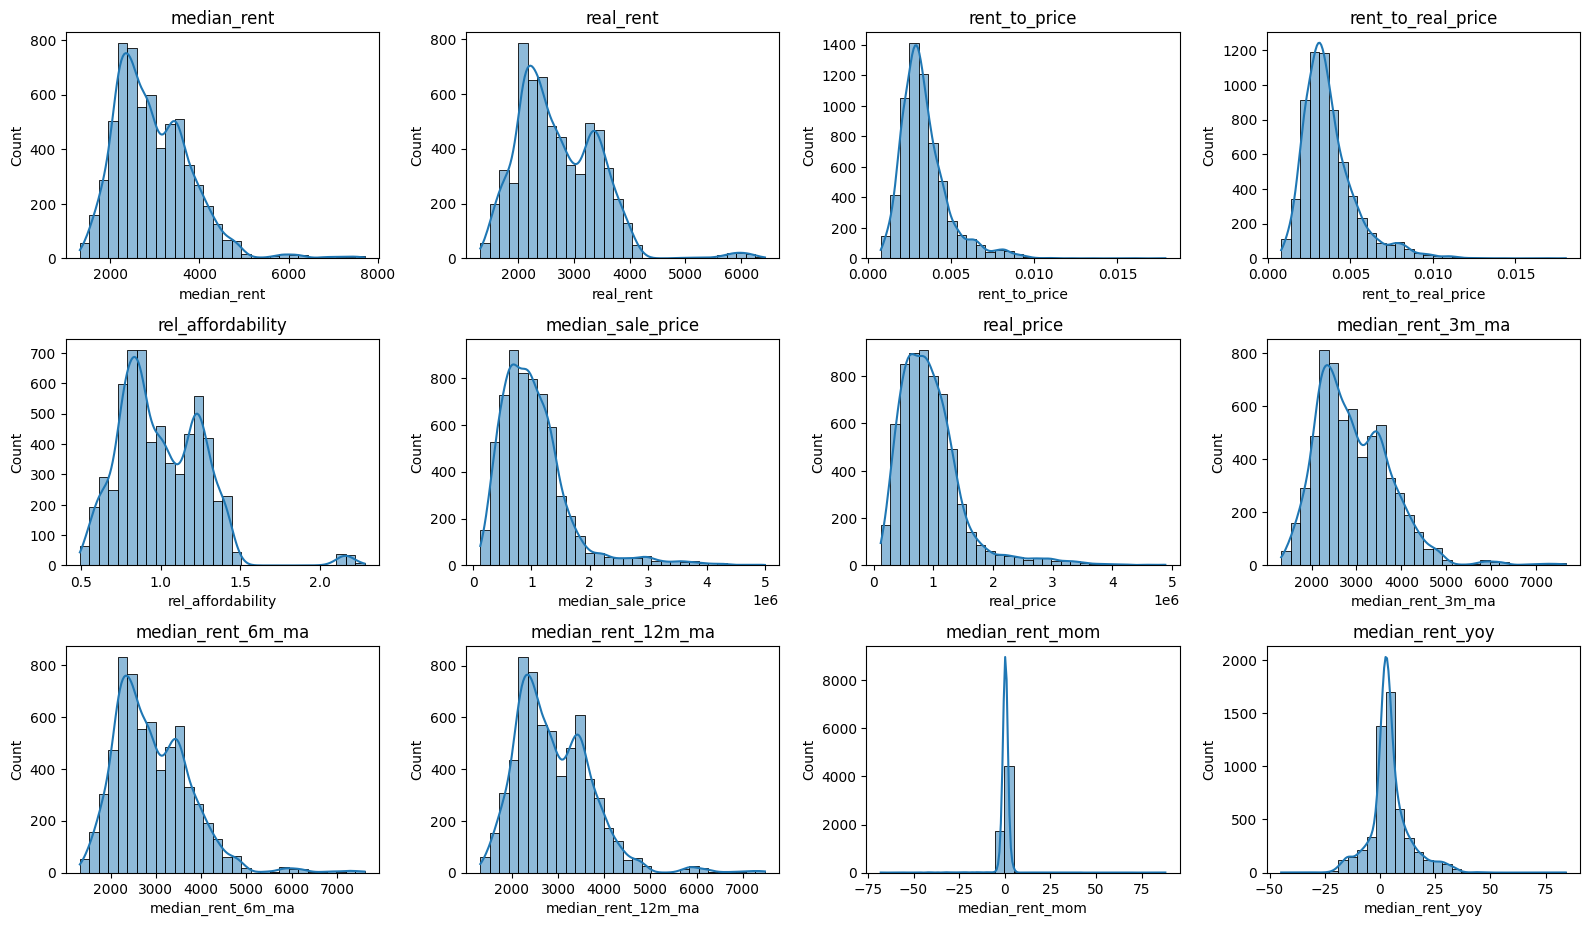

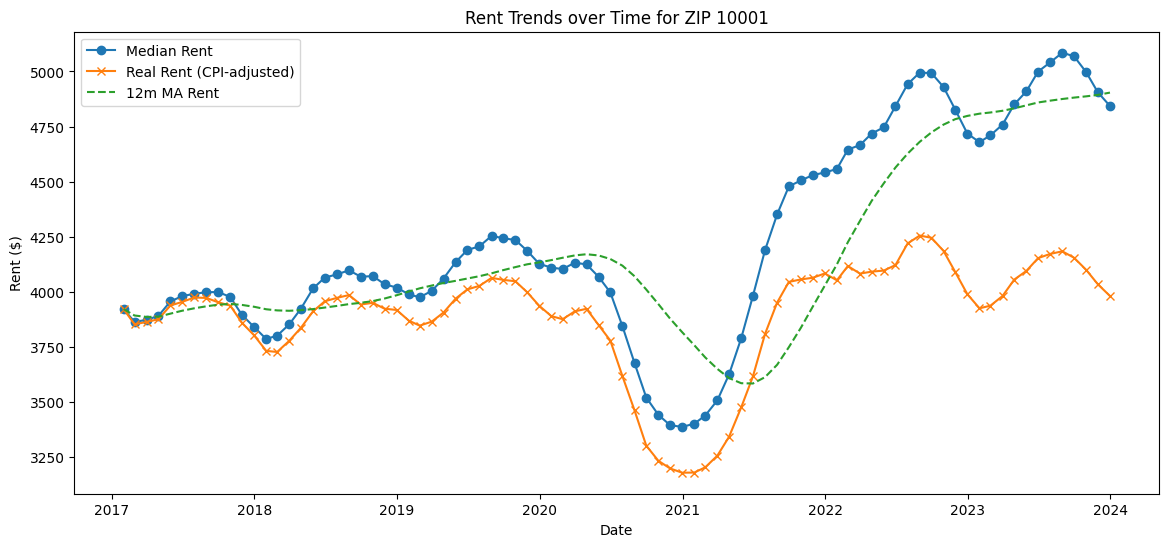

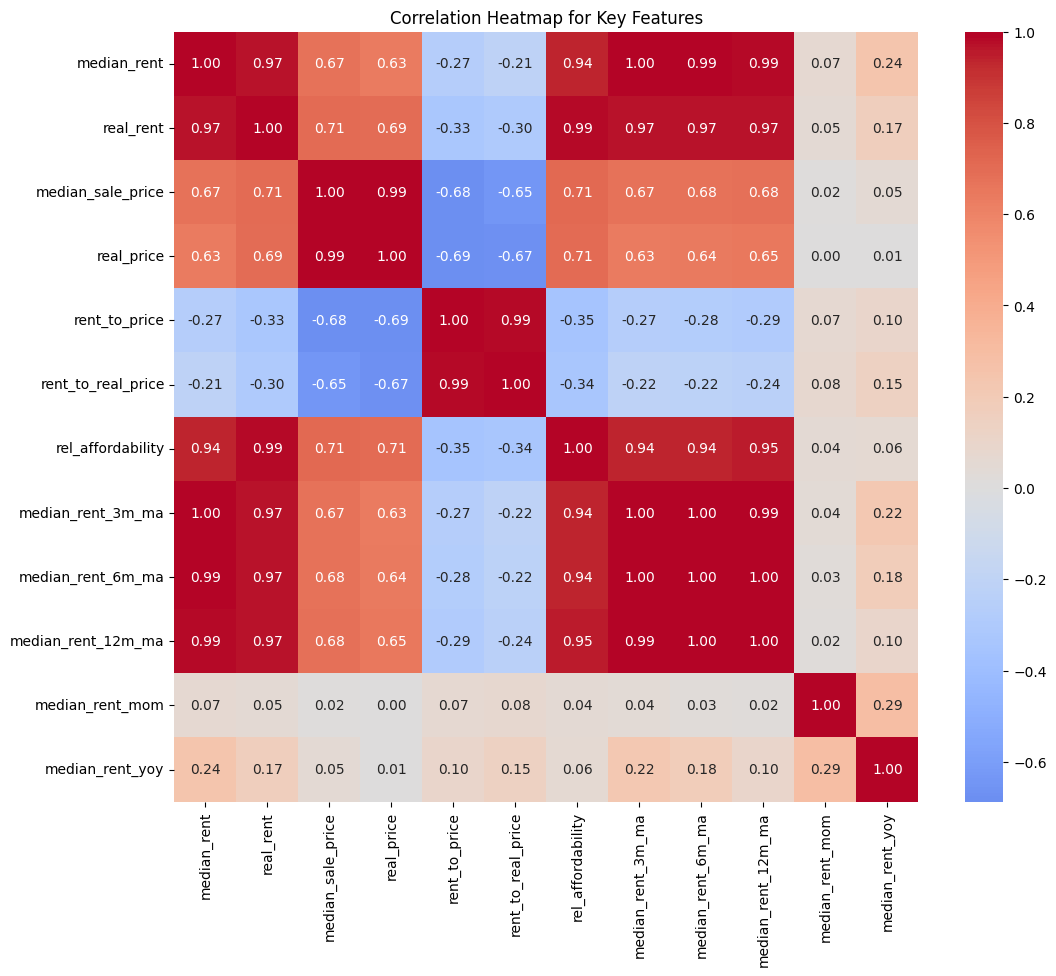

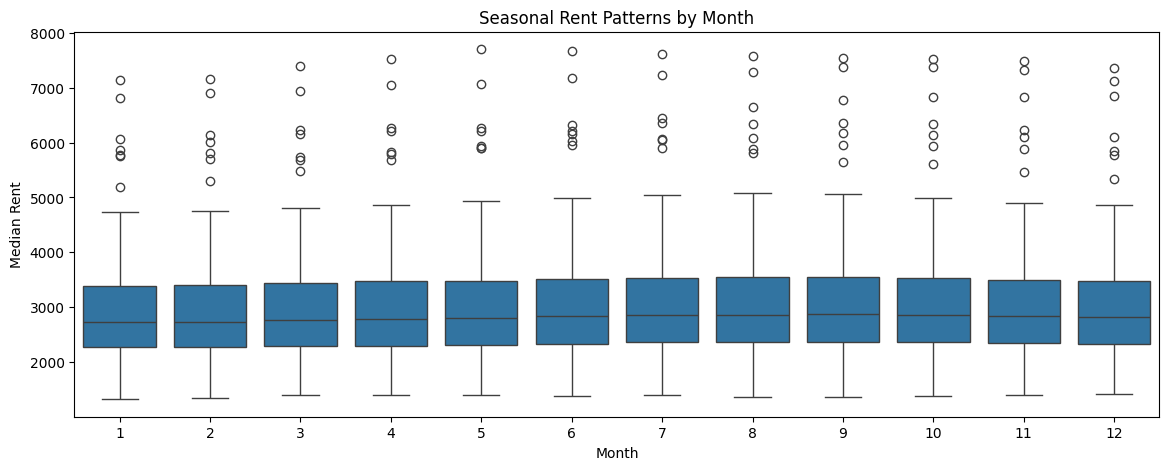

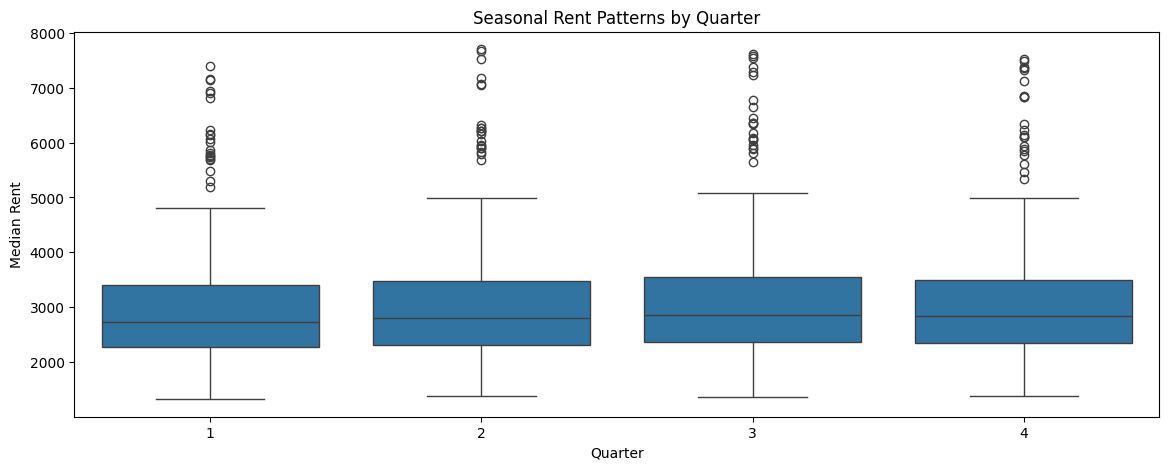

In [135]:

# # Overview & missing values
# # --------------------------
# print(house_data_nyc.describe())
# print(house_data_nyc.isnull().sum())

# # Distribution plots
# # --------------------------
# features_to_plot = [
#     'median_rent', 'real_rent', 'rent_to_price', 'rent_to_real_price',
#     'rel_affordability', 'median_sale_price', 'real_price',
#     'median_rent_3m_ma', 'median_rent_6m_ma', 'median_rent_12m_ma',
#     'median_rent_mom', 'median_rent_yoy'
# ]

# plt.figure(figsize=(16, 12))
# for i, col in enumerate(features_to_plot, 1):
#     plt.subplot(4, 4, i)
#     sns.histplot(house_data_nyc[col].dropna(), kde=True, bins=30)
#     plt.title(col)
# plt.tight_layout()
# plt.show()

# # Trend over time (sample ZIP code)
# # --------------------------
# sample_zip = house_data_nyc['zipcode'].iloc[0]  # pick first zip code
# zip_data = house_data_nyc[house_data_nyc['zipcode'] == sample_zip]

# plt.figure(figsize=(14,6))
# plt.plot(zip_data['date'], zip_data['median_rent'], label='Median Rent', marker='o')
# plt.plot(zip_data['date'], zip_data['real_rent'], label='Real Rent (CPI-adjusted)', marker='x')
# plt.plot(zip_data['date'], zip_data['median_rent_12m_ma'], label='12m MA Rent', linestyle='--')
# plt.title(f'Rent Trends over Time for ZIP {sample_zip}')
# plt.xlabel('Date')
# plt.ylabel('Rent ($)')
# plt.legend()
# plt.show()

# # Correlation heatmap
# # --------------------------
# corr_cols = ['median_rent','real_rent','median_sale_price','real_price',
#              'rent_to_price','rent_to_real_price','rel_affordability',
#              'median_rent_3m_ma','median_rent_6m_ma','median_rent_12m_ma',
#              'median_rent_mom','median_rent_yoy']

# plt.figure(figsize=(12,10))
# sns.heatmap(house_data_nyc[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
# plt.title('Correlation Heatmap for Key Features')
# plt.show()

# # Seasonal patterns
# # --------------------------
# plt.figure(figsize=(14,5))
# sns.boxplot(data=house_data_nyc, x='month', y='median_rent')
# plt.title('Seasonal Rent Patterns by Month')
# plt.xlabel('Month')
# plt.ylabel('Median Rent')
# plt.show()

# plt.figure(figsize=(14,5))
# sns.boxplot(data=house_data_nyc, x='quarter', y='median_rent')
# plt.title('Seasonal Rent Patterns by Quarter')
# plt.xlabel('Quarter')
# plt.ylabel('Median Rent')
# plt.show()